##**Task 2: Predict Future Stock Prices (Short-Term)**

### **Problem Statement**:
Use historical stock data to predict the next day's closing price.

### **Objective:**
To build a model that can accurately predict the next day's closing price of a selected stock using historical data.

- **INSTALL THE `yfinance` LIBRARY TO FETCH STOCK DATA.**

In [ ]:
pip install yfinance

- **IMPORT THE NECESSARY LIBRARIES, SELECT A STOCK, AND DOWNLOAD ITS HISTORICAK DATA**

In [ ]:
import yfinance as yf
import pandas as pd

# Define the stock ticker symbol (e.g., Apple, Tesla)
# You can change this to any stock you are interested in.
stock_ticker = 'AAPL'  # Apple Inc.

# Define the date range for historical data
start_date = '2021-01-01'
end_date = '2024-12-31'

# Download historical data
df = yf.download(stock_ticker, start=start_date, end=end_date)

# Display the first 5 rows of the DataFrame
display(df.head())

/tmp/ipykernel_2510/3055584976.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-01-04,125.740883,129.821799,123.166016,129.734354,143301900
2021-01-05,127.295471,128.004784,124.788620,125.235584,97664900
2021-01-06,123.010506,127.334339,122.796742,124.098753,155088000
2021-01-07,127.208046,127.897922,124.234808,124.720632,109578200
2021-01-08,128.306046,128.869603,126.537640,128.675261,105158200


- **DATA PREPROCESSING**

In [ ]:
# Create the target variable: 'Next_Close' (the closing price of the next day)
df['Next_Close'] = df['Close'].shift(-1)

# Drop rows with NaN values that result from shifting (the last row will have NaN for 'Next_Close')
df.dropna(inplace=True)

# Check for any other missing values in the DataFrame
print("Missing values after creating target variable:\n", df.isnull().sum())

# Display the first few rows with the new 'Next_Close' column
display(df.head())

Missing values after creating target variable:
 Price       Ticker
Close       AAPL      0
High        AAPL      0
Low         AAPL      0
Open        AAPL      0
Volume      AAPL      0
Next_Close            0
dtype: int64


Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400,71.630646
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800,72.201416
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,71.861855
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000,73.017822
2020-01-08,73.017822,73.318862,71.565606,71.565606,132079200,74.568802


- **FEATURE SELECTION AND DATA SPILITTING**


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
features = ['Open', 'High', 'Low', 'Volume']
X = df[features]
y = df['Next_Close']

# Split the data into training and testing sets
# We'll use a traditional time series split where earlier data is for training and later for testing.
# For simplicity here, we'll use train_test_split with shuffle=False to maintain temporal order.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

display(X_train.head())

Training data shape: (804, 4)
Testing data shape: (201, 4)


Price,Open,High,Low,Volume
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2020-01-02,71.344039,72.394070,71.091169,135480400
2020-01-03,71.563213,72.389265,71.406674,146322800
2020-01-06,70.754021,72.239950,70.503554,118387200
2020-01-07,72.211056,72.466338,71.642697,108872000
2020-01-08,71.565606,73.318862,71.565606,132079200


- **MODEL TRAINING: LINEAR REGRESSION**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model training complete. Predictions made on the test set.")

Model training complete. Predictions made on the test set.


- **MODEL EVALUATION**

In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Squared Error (MSE): 4.94
R-squared (R2 Score): 0.96


- **PLOTTING A GRAPH**

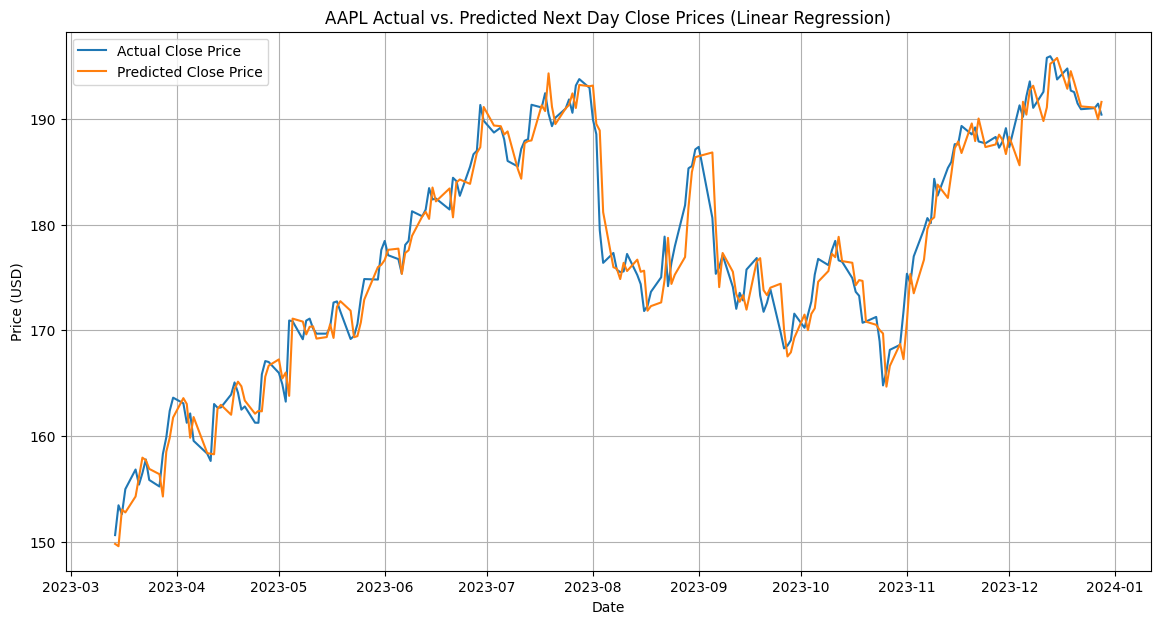

In [ ]:
import matplotlib.pyplot as plt

# Create a DataFrame for plotting
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)

# Plot the actual vs predicted prices
plt.figure(figsize=(14, 7))
plt.plot(predictions_df['Actual'], label='Actual Close Price')
plt.plot(predictions_df['Predicted'], label='Predicted Close Price')
plt.title(f'{stock_ticker} Actual vs. Predicted Next Day Close Prices (Linear Regression)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()